# Twitter Sentiment Analysis
Binary sentiment classification (positive/negative) using NLP pipeline
CountVectorizer + Logistic Regression + GridSearchCV + pickle serialization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
os.makedirs('images', exist_ok=True)

In [3]:
# Load dataset 
data = pd.read_csv('data/twitter_data.csv')
df = data[['tweet', 'label']].copy()
# label: 1 = negative, 0 = positive
print(df.shape)
df.head()

(7920, 2)


,tweet,label
0,#fingerprint #Pregnancy Test https://goo.gl/h1...,0
1,Finally a transparant silicon case ^^ Thanks t...,0
2,We love this! Would you go? #talk #makememorie...,0
3,I'm wired I know I'm George I was made that wa...,0
4,What amazing service! Apple won't even talk to...,1


In [4]:
# Basic checks
print('Null values:', df.isnull().sum())
print('Duplicates:', df.duplicated().sum())
df.drop_duplicates(inplace=True)
print('Shape after dedup:', df.shape)

Null values: tweet    0
label    0
dtype: int64
Duplicates: 2
Shape after dedup: (7918, 2)


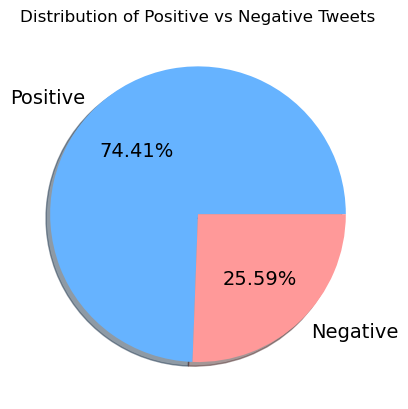

In [5]:
# Label distribution
p = df['label'].value_counts()
plt.title('Distribution of Positive vs Negative Tweets')
plt.pie(p, labels=['Positive', 'Negative'], autopct='%0.2f%%',
        shadow=True, colors=['#66b3ff', '#ff9999'],
        textprops={'fontsize': 14})
plt.savefig('images/sentiment_distribution.png', bbox_inches='tight')
plt.show()

In [6]:
# Feature engineering - text, word, sentence lengths
import nltk
nltk.download('punkt')
nltk.download('stopwords')

df['text_length'] = df['tweet'].apply(len)
df['word_length'] = df['tweet'].apply(lambda x: len(nltk.word_tokenize(x)))
df['sent_length'] = df['tweet'].apply(lambda x: len(nltk.sent_tokenize(x)))

[nltk_data] Downloading package punkt to C:\Users\TRN
[nltk_data]     Srinivas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\TRN
[nltk_data]     Srinivas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


C:\Users\TRN Srinivas\Anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\TRN Srinivas\Anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\TRN Srinivas\Anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\TRN Srinivas\Anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf va

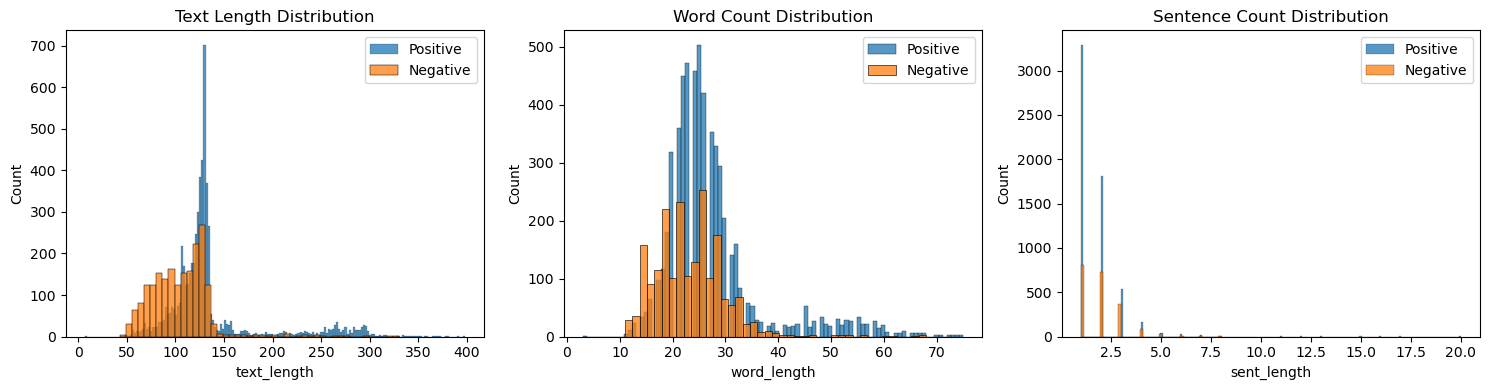

In [7]:
# EDA - length distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in zip(axes,
    ['text_length', 'word_length', 'sent_length'],
    ['Text Length', 'Word Count', 'Sentence Count']):
    sns.histplot(df[df['label']==0][col], label='Positive', ax=ax)
    sns.histplot(df[df['label']==1][col], label='Negative', ax=ax)
    ax.set_title(f'{title} Distribution')
    ax.legend()

plt.tight_layout()
plt.savefig('images/length_distributions.png', bbox_inches='tight')
plt.show()

In [8]:
# Text preprocessing
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

ps = PorterStemmer()

def transform_text(text):
    # lowercase
    text = text.lower()
    # tokenize
    text = nltk.word_tokenize(text)
    # keep alphanumeric only
    text = [i for i in text if i.isalnum()]
    # remove stopwords and punctuation
    text = [i for i in text if i not in string.punctuation
            and i not in stopwords.words('english')]
    # stemming
    text = [ps.stem(i) for i in text]
    return ' '.join(text)

df['transformed_text'] = df['tweet'].apply(transform_text)
df = df[['transformed_text', 'label']].copy()
df.head()

,transformed_text,label
0,fingerprint pregnanc test http android app bea...,0
1,final transpar silicon case thank uncl yay son...,0
2,love would go talk makememori unplug relax iph...,0
3,wire know georg made way iphon cute daventri h...,0
4,amaz servic appl wo even talk question unless ...,1


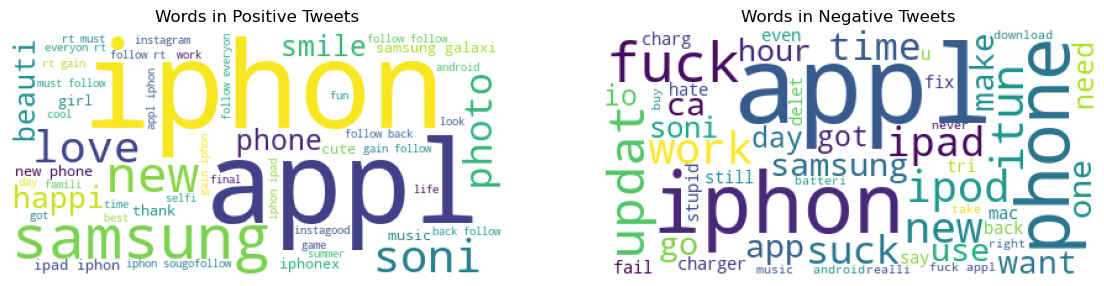

In [9]:
# WordCloud visualizations
import os
os.makedirs('images', exist_ok=True)
from wordcloud import WordCloud

wc = WordCloud(max_words=50, background_color='white')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(wc.generate(df[df['label']==0]['transformed_text'].str.cat(sep=' ')))
axes[0].set_title('Words in Positive Tweets')
axes[0].axis('off')

axes[1].imshow(wc.generate(df[df['label']==1]['transformed_text'].str.cat(sep=' ')))
axes[1].set_title('Words in Negative Tweets')
axes[1].axis('off')

plt.savefig('images/wordclouds.png', bbox_inches='tight')
plt.show()

In [10]:
# Vectorization
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

cv = CountVectorizer(max_features=10000)
X = cv.fit_transform(df['transformed_text']).toarray()
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (6334, 10000)
Test shape: (1584, 10000)


In [11]:
# Baseline Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix

model = LogisticRegression(penalty='l2', solver='liblinear')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)

print('Train Accuracy:', accuracy_score(y_train, y_pred_train))
print('Test Accuracy: ', accuracy_score(y_test, y_pred))
print('Test Precision:', precision_score(y_test, y_pred))

Train Accuracy: 0.9657404483738554
Test Accuracy:  0.8876262626262627
Test Precision: 0.788659793814433


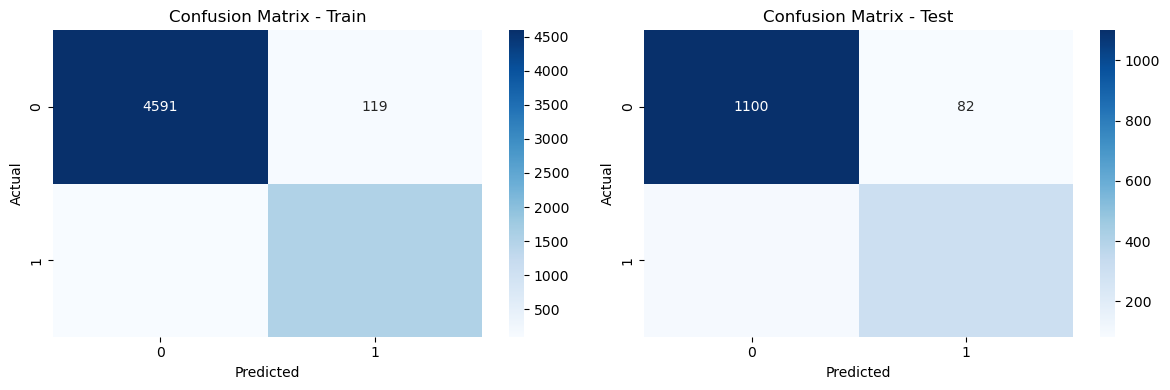

In [12]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(y_train, y_pred_train), annot=True, fmt='d',
            ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix - Train')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            ax=axes[1], cmap='Blues')
axes[1].set_title('Confusion Matrix - Test')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('images/confusion_matrices.png', bbox_inches='tight')
plt.show()

In [14]:
# Hyperparameter tuning with GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print('Best Parameters:', grid.best_params_)
print('Best CV Score:  ', grid.best_score_)

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)
print('Test Accuracy (Best Model):', accuracy_score(y_test, y_pred_best))
print('Test Precision (Best Model):', precision_score(y_test, y_pred_best, average='weighted'))

Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV Score:   0.8796981587534335
Test Accuracy (Best Model): 0.8914141414141414
Test Precision (Best Model): 0.8904438665745199


In [15]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.92      0.93      0.93      1182
           1       0.79      0.77      0.78       402

    accuracy                           0.89      1584
   macro avg       0.86      0.85      0.86      1584
weighted avg       0.89      0.89      0.89      1584



In [16]:
from sklearn.metrics import roc_auc_score
print('ROC-AUC:', roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1]))

ROC-AUC: 0.9494300915052486


In [17]:
# Feature importance - top words driving sentiment
feature_names = cv.get_feature_names_out()
coefficients = best_model.coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefficients})
coef_df = coef_df.sort_values('coefficient', ascending=False)

print('Top 10 Positive words:')
print(coef_df.head(10)[['feature', 'coefficient']])
print('\nTop 10 Negative words:')
print(coef_df.tail(10)[['feature', 'coefficient']])

Top 10 Positive words:
       feature  coefficient
3199      fuck     1.085696
7866      suck     0.961078
3208   fuckyou     0.882926
3476  hateappl     0.842377
3475      hate     0.746600
2781      fail     0.680736
8947     updat     0.656937
7829    stupid     0.577111
1137   charger     0.566553
372      annoy     0.468897

Top 10 Negative words:
          feature  coefficient
1752         cute    -0.599647
5458  photographi    -0.619640
592        beauti    -0.658957
1030         case    -0.692815
3459        happi    -0.710681
6654      samsung    -0.745277
3877      iphonex    -0.817847
4225         love    -0.864736
3107       follow    -0.878393
3614         http    -1.989195


In [18]:
# Save model and vectorizer
import pickle

pickle.dump(cv, open('vectorizer.pkl', 'wb'))
pickle.dump(best_model, open('model.pkl', 'wb'))
print('Model and vectorizer saved.')

Model and vectorizer saved.


In [19]:
# Inference on new tweet
with open('vectorizer.pkl', 'rb') as f:
    loaded_vec = pickle.load(f)
with open('model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

def predict_sentiment(tweet):
    cleaned = transform_text(tweet)
    vectorized = loaded_vec.transform([cleaned]).toarray()
    prediction = loaded_model.predict(vectorized)[0]
    label = 'Negative' if prediction == 1 else 'Positive'
    return label

# Test
print(predict_sentiment("I love this product!"))
print(predict_sentiment("This is absolutely terrible."))

Positive
Negative
